# Machine Learning Assignment 1

### Step 1: Identifying the Prediction Target

In [2]:
#%pip install numpy
#%pip install pandas
#%pip install -U scikit-learn
#%pip install matplotlib-inline

In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("bank-additional.csv", sep=";")
df.shape

(4119, 21)

In [5]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


The target variable is already labeled as "**y**" and it is a binary variable, leading me to think that this problem could be solved through logistic regression. Next I will separate it from the rest of the dataset. This variable is best for this prediction as it directly is the measure of weather the client subscribed or not. In the case of this marketing campaign, this is the main goal as we are trying to get as many customers to subscribe as possible.

In [6]:
X = df.drop("y", axis = 1)
y = df["y"]

From the dataset that 3 other variable could be seen as the target variable superficially. Firstly, '**duration**', which is the time in seconds that the call took. This variables should not be used as it does not really predict if the customer subscribed or not. This should be a predictor as it could even cause leakage as you only get this data after the phone call ended (after y). The second variable that could be considered a target is '**campaign**', which represents the number of contacts performed during this campaign for the client. Although this might seem like the target as it is directly related to the campaign, it does not indicate teh success of the campaign at all but rather if the campaign was operating efficiently. Finally, the last variable that seemed it could be the target to me is '**pdays**' which shows the number of days since last contact. This variable could seem as the target as one could infer that if the number of days is low, then the campaign did succeed. But again it isnt the target as it does not directly tell you if it succeeded or not, and again I think this could cause leakage.

### Step 2: Data Loading and Exploration

In [7]:
import matplotlib.pyplot as plt

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

In [9]:
df.dtypes

age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

We have 19 variables. 10 are numerical and 9 are categorical variables. The code above shows their specific type. From hindsight, the code says that there are no missing values but when looking at the table itself there are some, but they are labeled as unknown. I will now split the numerical and categorical variables

In [10]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


This shows that the scales are extremely different for most variables and again shows that there of no missing values. Below I will do the same but for categorial variables.

In [17]:
df.describe(exclude="number")

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,1012,2509,1264,3315,2175,3349,2652,1378,860,3523,3668


Now I will identify which are categorical and which are numerical which can be done with a simple command.

In [15]:
numerical_cols = X.select_dtypes(include="number").columns
categorical_cols = X.select_dtypes(exclude="number").columns

print("Numerical columns:", list(numerical_cols))
print("Categorical columns:", list(categorical_cols))

Numerical columns: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


Now we look at the target variable and analyze it by itself -->

In [16]:
y.value_counts()

y
no     3668
yes     451
Name: count, dtype: int64

In [18]:
y.value_counts(normalize=True) * 100

y
no     89.05074
yes    10.94926
Name: proportion, dtype: float64

We can see from this code that there are 3668 no's and only 451 yes's which make the data extremely imbalanced being an issue for the model in the future. This be an issue for precision and recall as almost 90% of the data are no's. Next we move onto missing values detection which has already been discussed previously.

In [19]:
df.isna()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4114,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4115,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4116,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4117,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Again we can see that the data shows no missing values, but it does have missingness labeled as Unknown as mentioned before. To identify and analyze these, I have to use different code to find and count these values.

In [23]:
unknown_counts = (df[categorical_cols] == "unknown").sum()
unknown_counts

job             39
marital         11
education      167
default        803
housing        105
loan           105
contact          0
month            0
day_of_week      0
poutcome         0
dtype: int64

Here we can clearly see that there are missing values now. Luckily, in 4 variables there isnt a single missing value, and overall in proportion to teh total data amount, the only variable that has a significant amount of missing values according to the rule of thumb is '**default**' with 803. The others have less than 10% of missingness which is very good.

After going back and analyzing the variable again, I have found that it specifically represents whether the client currently has credit in default (i.e., failed to repay a loan).The large number of "unknown" entries suggests that the bank did not have reliable information about clients’ default status. This represents implicit missingness rather than random noise. For this reason, I believe that these unknowns should be kept as unknowns rather that replacing them as missing values (which they are not exactly) due to them carrying information. If I were to impute them, they may skew the data and mess up the model as they may have predictive power themselves.

Now we move onto visualizing the variables:

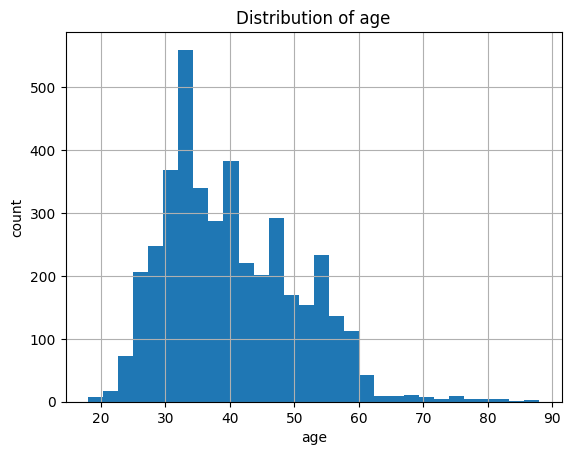

In [24]:
df["age"].hist(bins=30)
plt.title("Distribution of age")
plt.xlabel("age")
plt.ylabel("count")
plt.show()

The distribution of '**age**' seems close to normal, although it has very high spikes. The values seems balanced which is good moving forward.

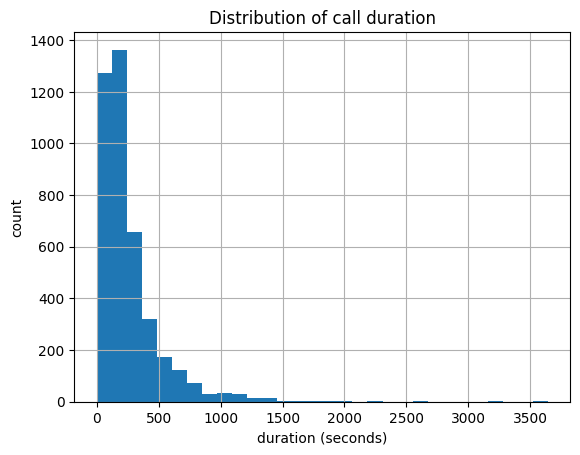

In [25]:
df["duration"].hist(bins=30)
plt.title("Distribution of call duration")
plt.xlabel("duration (seconds)")
plt.ylabel("count")
plt.show()

'**duration**' requires special consideration because it is only known after the call has occurred, meaning that it could cause leakage. Additionally it seems that the data is very zero inflated which might be an issue. In any case, this variables should need special consideration.

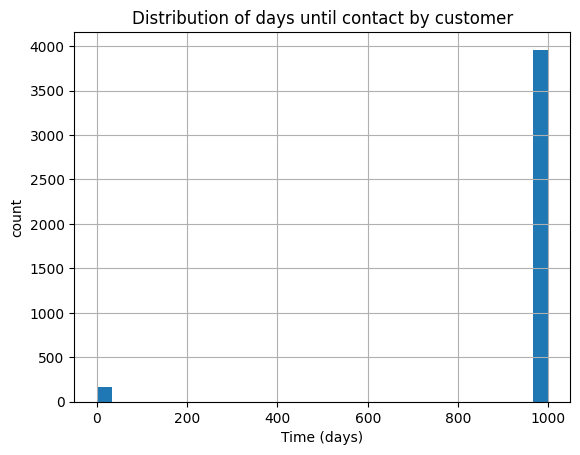

In [26]:
df["pdays"].hist(bins=30)
plt.title("Distribution of days since last contact from customer")
plt.xlabel("Time (days)")
plt.ylabel("count")
plt.show()

After going back to the data and analyzing it, I found that the variable '**pdays**' contains a sentinel value of 999, which indicates that the client was not previously contacted. This creates a large spike in the distribution. Therefore, 999 does not represent an actual number of days and should be graphed to analyze distribution without this value.

This suggests that '**pdays**' may need special preprocessing, as these values could be treated as missing or set as a new variables that shows if the customer has been called before (binary).

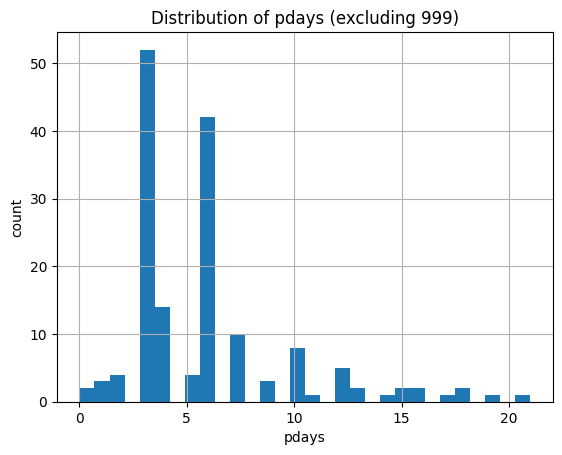

In [27]:
plt.figure()
df[df["pdays"] != 999]["pdays"].hist(bins=30)
plt.title("Distribution of pdays (excluding 999)")
plt.xlabel("pdays")
plt.ylabel("count")
plt.show()

This variable is very skewed and have a high range of values with most being small and close to 0.

Now lets move onto the categorical variables.

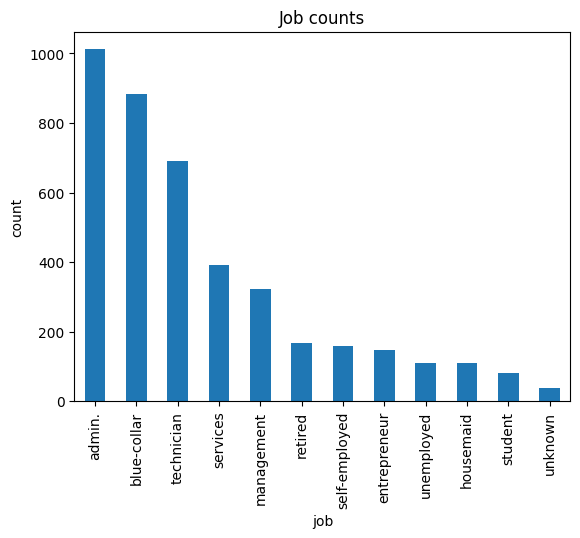

In [28]:
df["job"].value_counts().plot(kind="bar")
plt.title("Job counts")
plt.xlabel("job")
plt.ylabel("count")
plt.show()


The variable '**job**' seems to be ok so far, and I believe could have a lot of predictive power, due to its many categories. Looking at the graph we can see that most values come from 'admin','blue-collar', and 'technician'.

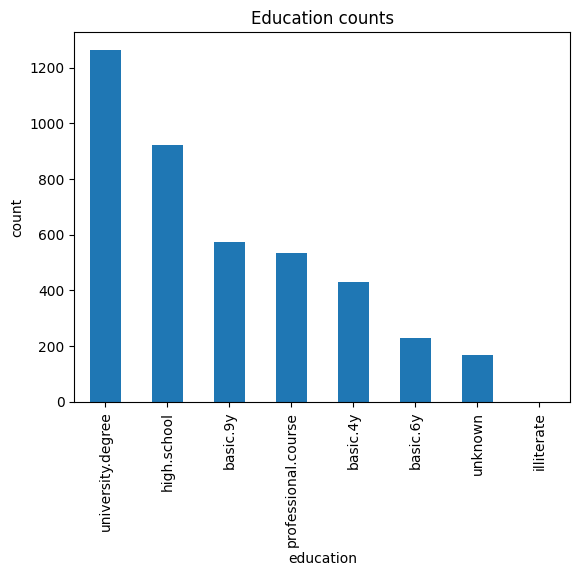

In [29]:
df["education"].value_counts().plot(kind="bar")
plt.title("Education counts")
plt.xlabel("education")
plt.ylabel("count")
plt.show()

Again, the graph for '**education**' seems to be ok. The issue I find from it is that there seems to be close to no values for 'illiterate', but it seems fitting to the data as most people who are called are not illiterate.

After analyzing this variable more closely I find that it may require special consideration because it is an ordinal categorical variable. The levels have a natural ordering (illiterate < basic.4y < basic.6y < high.school < university.degree).
Treating it as nominal ignores this detail. Therefore, the encoding strategy must be carefully justified.
Additionally, the presence of the category "unknown" introduces implicit missingness that
requires a modeling decision.

### **Step 3: Data Splitting**

In [31]:
from sklearn.model_selection import train_test_split

First we will split only into train and test and the sklearn library allows me to do so with one simple line.

In [36]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=2026)

Now we basically replicate this code, but to split the test into validation and test:

In [37]:
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=2026)

**Why this split of 70, 15, 15?**

I decided to split the dataset into 70% training, 15% validation, and 15% test sets.
The training set is kept large to allow stable parameter estimation and that is why I kept 70% instead of 60%. Even like this, the training and validation sets are suficiently large enough to provide reliable performance in the model. I want the data to be very well trained with a lot of data.

**Why did I choose to stratify the target(y)?**

I made the decision to stratify the data with the purpose of preserving the original class distribution of the target variable across all splits. Since the dataset is extremely imbalanced, non-stratified splitting could result in validation or test sets with disproportionate class representation, leading to what could be unreliable results.

**Why splitting must happen before preprocessing?**

The dataset must be split before performing any transformation that learns parameters from the data such as scaling or imputing, which are the remaining steps in this assignment. It is crucial to do the splitting at this step as if transformations are fitted before splitting, information from validation or test sets may leak into the training process, leading to overly optimistic performance estimates.

**What types of data leakage could arise specifically?**

If the dataset were split only after preprocessing, several types of data leakage could occur. First, there could be **information leakage through preprocessing**, where statistics such as means or standard deviations are computed on the full dataset before splitting, allowing validation and test data to influence how the training data is transformed. During data acquisition and feature engineering, there is also a risk of the unintentional introduction of information about the target. This can lead to **target leakage**, where the target is directly or indirectly encoded in another feature, or through **proxy features**, where another variable is strongly correlated with the target in a biased way. There is also the risk of **temporal leakage** if features include information collected after the prediction time, meaning the model would be learning from the future. Additionally, improper data partitioning can cause **group leakage**, where related samples appear in both training and validation/test sets, leading  to the violation of statistical independence.

### **Step 4: Managing Missing Values**

In [41]:
#Recheck explicit missing values on each split of data
nan_train = X_train.isna().sum().sort_values(ascending=False)
nan_val   = X_val.isna().sum().sort_values(ascending=False)
nan_test  = X_test.isna().sum().sort_values(ascending=False)

print("NaN in train set:")
print(nan_train[nan_train > 0])

print("\nNaN in val set:")
print(nan_val[nan_val > 0])

print("\nNaN in test set:")
print(nan_test[nan_test > 0])

NaN in train set:
Series([], dtype: int64)

NaN in val set:
Series([], dtype: int64)

NaN in test set:
Series([], dtype: int64)


Again we see that there are no explicit missing values in any of the data splits. We will now check for unknowns within each split. This has already been done, but not for each split of data now, so this will make it more clear and visual.

In [42]:
unknown_train = (X_train[categorical_cols] == "unknown").sum().sort_values(ascending=False)
unknown_val   = (X_val[categorical_cols] == "unknown").sum().sort_values(ascending=False)
unknown_test  = (X_test[categorical_cols] == "unknown").sum().sort_values(ascending=False)

print("Unknown counts (train):")
print(unknown_train[unknown_train > 0])

print("\nUnknown counts (val):")
print(unknown_val[unknown_val > 0])

print("\nUnknown counts (test):")
print(unknown_test[unknown_test > 0])

Unknown counts (train):
default      558
education    111
housing       71
loan          71
job           26
marital        6
dtype: int64

Unknown counts (val):
default      122
education     19
housing       19
loan          19
job            8
marital        4
dtype: int64

Unknown counts (test):
default      123
education     37
housing       15
loan          15
job            5
marital        1
dtype: int64


Now I will check for the sentinel value that I know exists in '**pdays**' from my previous research:

In [44]:
sentinel_pdays_train = (X_train["pdays"] == 999).sum()
sentinel_pdays_val   = (X_val["pdays"] == 999).sum()
sentinel_pdays_test  = (X_test["pdays"] == 999).sum()

print("train:", sentinel_pdays_train)
print("val:", sentinel_pdays_val)
print("test:", sentinel_pdays_test)

train: 2778
val: 590
test: 591


Verify these as percentages now -->

In [45]:
print("Sentinel values in train:", (X_train["pdays"] == 999).mean() * 100)

pdays == 999 percentage in train: 96.3579604578564


After going back and checking the values for all numerical variables I understand that '**pdays**' is the only feature containing a sentinel value (999), which represents that the client was not previously contacted. No other numerical feature contains artificial codes representing non-measurement states. Other numeric variables represent genuine counts.

Now I want to quantify the extent of missingness (specifically unknown values as they are the only that exist) together so I can come back to the following cell more easily. I now am starting to work only with the training set as this is the only one in which imputation should be done due to leakage.

In [53]:
unknown_count = (X_train[categorical_cols] == "unknown").sum()
unknown_count[unknown_count > 0]

job           26
marital        6
education    111
default      558
housing       71
loan          71
dtype: int64

This shows the exact number of missing values in each variable, those that do not show up, have no missing values at all. We can see that similar to what we saw before the split, default is the variable with the highest number of missing values.

Handling the sentinel value (999) in '**pdays**':

Treating 999 as a genuine numeric value would distort the feature as had been seen in the previous step and mislead the model into interpreting it as an extreme magnitude. Therefore, I would suggest that the sentinel value should ne handled explicitly by transforming '**pdays**' into two components: (1) a new binary variable representing whether the client was previously contacted, and (2) a cleaned numerical variable where 999 is replaced with a neutral value such as 0 in order to preserve a cleaner distribution of the data. This preserves the semantic meaning of the original feature while preventing inappropriate scaling and coefficient distortion in the Logistic Regression model.

Handling missingness for each variable 1 by 1:

The variable **job** contains a small number of "unknown" entries which is also a very small proportion of the data itself. Since missingness is limited and may reflect an absence information rather than random noise, the "unknown" category should be preserved as its own category during later steps such as encoding. This allows the model to learn whether the absence of job information carries predictive value without introducing imputation bias.

The variable **marital** contains very few "unknown" values, only 6 in total. Given the insignificant proportion, "unknown" should be retained as a separate category rather than imputed. Removing or imputing these entries would provide little to no benefit and may unnecessarily distort the data distribution.

The variable **education** contains a higher but still low number of "unknown" values. Since education level is an ordinal categorical variable and missingness may reflect unrecorded information rather than random absence similarly to the other variables, the "unknown" category should be retained. This approach avoids imposing artificial ordering assumptions through imputation.

The variable **default** is only one that contains a larger proportion of "unknown" values, suggesting that credit default status was frequently unrecorded. I belive this can be infered due to the nature of the variable. Rather than imputing these values, "unknown" will be preserved as a distinct category. This reflects the real-world availability of information and prevents the introduction of artificial assumptions. However, the high proportion of missingness suggests that this variable may have limited predictive power and should be re-evaluated during feature selection as it may not be completely necessary and even cause overfitting.

The variable **housing** includes also contains a limited number of "unknown" entries. These again should be preserved as a separate category, as they represent real uncertainty in the data rather than measurement error.

Similar to **housing**, the variable loan contains a small number of "unknown" values which could gave predictive power themselves. Overall, due to the similar argument of a small proportion of missing values and what their absence may mean, I suggest that all "unknown" values are kept as their own separate category without any imputation which could cause more harm than good in the data.

### Step 5: Encoding Categorical Variables